# Yandex AI Studio

В этом демонстрационном ноутбуке мы пройдём полный мультимодальный сценарий на данных
из открытой онлайн-коллекции Государственного музея изобразительных искусств имени
А. С. Пушкина. Один и тот же экспонат будет сопровождать нас на всех этапах, поэтому
результат каждой модели можно будет сравнить с исходными музейными данными.

Мы последовательно:

1. подключимся к Yandex AI Studio через OpenAI-совместимый Responses API;
2. сделаем простой запрос к LLM и продолжим диалог с сохранением контекста;
3. загрузим локальный музейный датасет и адаптируем описание для ребёнка 10 лет;
4. извлечём из полного текста типизированные смысловые теги;
5. передадим изображение экспоната мультимодальной модели (VLM), сначала получив обычный текст, а затем структурированный результат;
6. озвучим доступное визуальное описание с помощью SpeechKit;
7. создадим новую художественную интерпретацию экспоната с помощью YandexART.

> Модельные ответы вероятностны: формулировки будут немного отличаться при каждом запуске.
> Выводы LLM и VLM — не замена научной атрибуции музейного специалиста.

## 0. Подготовка окружения

Для выполнения примеров понадобятся OpenAI-совместимый клиент, нативный SDK Yandex AI
Studio (для SpeechKit), Pydantic для структурного вывода, Pillow для изображений,
`requests` для загрузки фотографии и `python-dotenv` для чтения секретов.

Следующая ячейка устанавливает или обновляет эти библиотеки в окружении текущего ядра.
После первого выполнения может потребоваться перезапустить kernel и снова начать с этой
секции. Ключи доступа в команду установки не передаются.

In [ ]:
%pip install openai python-dotenv pydantic Pillow requests yandex-ai-studio-sdk tqdm


Теперь импортируем только те компоненты, которые используются дальше. `IPython.display`
нужен для показа музейной фотографии, воспроизведения WAV-файла и отображения
сгенерированной иллюстрации непосредственно в ноутбуке.

In [1]:
import base64
import io
import json
import os
from pathlib import Path
from tqdm.auto import tqdm

import requests
from dotenv import load_dotenv
from IPython.display import Audio, JSON, Markdown, display, Image as IPImage
from openai import OpenAI
from PIL import Image
from pydantic import BaseModel, Field
from yandex_ai_studio_sdk import AIStudio

c:\winapp\conda\envs\fresh\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Подключение к Yandex Cloud

Как и в учебном примере `CloudConnect.ipynb`, идентификатор каталога `folder_id` и
API-ключ `api_key` берутся из файла `.env`. Поместите `.env` в корень проекта или рядом с этим ноутбуком в таком виде:

```text
folder_id=ваш_идентификатор_каталога
api_key=ваш_api_ключ
```

In [2]:
load_dotenv(override=True)

folder_id = os.getenv("folder_id")
api_key = os.getenv("api_key")
if not folder_id or not api_key:
    raise RuntimeError(
        f"Добавьте folder_id и api_key в файл {env_path} и повторите ячейку."
    )

print(f"Folder ID: {folder_id[:8]}…")

Folder ID: b1gg3vl8…


Создадим единый объект `client` для всех вызовов Responses API и Images API. Параметр
`base_url` направляет стандартный OpenAI SDK в Yandex AI Studio, а `project=folder_id`
связывает запросы с каталогом Yandex Cloud.

Здесь также явно задаются URI трёх моделей:

- `deepseek_model` - ещё одна большая модель, которую рекомендуется использовать;
- `qwen36_model` — запросы с изображением;
- `yandex_art_model` — генерация изображения в демонстрации YandexART.

Также будет использовать переменную `model` для задания базовой модели на самые частые случаи.

In [3]:
client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

qwen36_model = f"gpt://{folder_id}/qwen3.6-35b-a3b"
deepseek_model = f"gpt://{folder_id}/deepseek-v4.1-flash"
yandex_art_model = f"art://{folder_id}/aliceai-image-art-3.0"

model = deepseek_model

## 2. Простой вызов LLM и продолжение диалога

Начнём с короткого запроса, не связанного с датасетом: попросим модель рассказать добрый
анекдот про искусство. Аргумент `instructions` задаёт роль и ограничения ответа, а `input`
содержит реплику пользователя.

In [4]:
joke_response = client.responses.create(
    model=model,
    instructions=(
        "Ты — доброжелательный музейный ведущий. Отвечай по-русски, кратко, "
        "без грубости и сомнительных исторических фактов."
    ),
    input="Расскажи анекдот про искусство.",
)

display(Markdown(joke_response.output_text))
print(f"ID ответа: {joke_response.id}")

Хороший вопрос — анекдот про искусство у нас как раз в постоянной экспозиции. Вот один:

Приходит посетитель в музей и спрашивает экскурсовода:
— Скажите, почему у этой античной статуи нет рук?
— Время не пощадило.
— А почему нет головы?
— Тоже время.
— А почему она так странно на меня смотрит?
— Это не статуя. Это наш охранник Иван Петрович. Тоже, кстати, античный — тридцать лет в одном зале.

Если хотите, могу подобрать что-нибудь ещё — например, про натюрморт или про то, почему в залах нельзя трогать экспонаты.

ID ответа: 709f46ab-e8c4-4111-b8d2-9c5c90fdc37f


Теперь продолжим именно этот диалог фразой «А про котиков?». Вместо повторной передачи
всей истории укажем `previous_response_id`. Модель получит контекст предыдущей шутки и
поймёт, что нужно рассказать ещё один анекдот — теперь про котиков и искусство.

In [5]:
cats_response = client.responses.create(
    model=model,
    previous_response_id=joke_response.id,
    input="А про котиков?",
)

display(Markdown(cats_response.output_text))

— В музее открыли выставку «Коты в искусстве». Экскурсовод ведёт группу:
— Перед вами «Мона Лиза», великий Леонардо...
Кот, сидевший на подоконнике, скидывает табличку.
— ...а это, дамы и господа, современное искусство. Автор — кот Барсик. Работа называется «Я и есть шедевр».

И ещё одна:

— Почему коты не ходят в картинные галереи?
— Потому что там нельзя ничего сбросить со стола. А какой тогда интерес?

## 3. Чтение музейного датасета и адаптация описания

Для получения датасета, запустите `scripts/prepare-data.py` для загрузки датасета из открытых данных Пушкинского музея. При этом создаётся упрощённый датасет в `data/pushkin.json`, который представляет собой JSON-массив.

В каждой записи есть название, тип объекта, страна, период, материал, полное музейное
описание, URL изображения и служебные поля. Загрузим все записи, а затем выберем какой-то из экспонатов для более детальных экспериментов с помощью `exhibit = exhibits[0]`.

In [6]:
dataset_path = "../data/pushkin.json"
with open(dataset_path, "r", encoding="utf-8") as file:
    exhibits = json.load(file)

exhibit = exhibits[0]

print(f"Всего экспонатов: {len(exhibits)}")
display(JSON(exhibit, indent=2, ensure_ascii=False))

Всего экспонатов: 97


<IPython.core.display.JSON object>

In [7]:
display(Markdown(f"![Image]({exhibit['image_url']})"))

![Image](https://pushkinmuseum.art/data/fonds/ancient_east/1_1_a/1_1_a_2103__2099/3675_foto_1_03.jpg)

Музейное описание рассчитано на взрослого читателя и содержит много исторических деталей.
Попросим LLM сократить его и объяснить экспонат ребёнку 10 лет. В инструкции явно запретим
придумывать факты и попросим сохранить важные сведения: кто изображён, когда и где создан
предмет, из чего он сделан и почему интересен.

Полученный текст сохраним как `child_description`: он пригодится как самостоятельная
детская этикетка, хотя перед публикацией её всё равно должен проверить редактор музея.

In [8]:
child_response = client.responses.create(
    model=model,
    instructions=(
        "Ты — редактор детского музея. Перепиши описание для ребёнка 10 лет. "
        "Используй простой русский язык, короткие предложения и 2–3 небольших абзаца. "
        "Сохрани только важные факты из источника, ничего не выдумывай. "
        "Если встречается сложный термин, сразу объясни его простыми словами."
    ),
    input=json.dumps(exhibit, ensure_ascii=False),
)

child_description = child_response.output_text.strip()
display(Markdown(f"### Детская этикетка\n\n{child_description}"))

### Детская этикетка

Это парные статуэтки. Одна изображает жреца Аменхотепа, а другая — его жену Раннаи. Жрец — это служитель бога в храме. Раннаи была певицей бога Амона. Статуэтки нашли в гробнице № 345 на древнем кладбище знати Шейх Абд эль-Курна, на западном берегу Фив. Их заказал сын этой пары.

Фигурки сделаны из ценного эбенового дерева. Его привозили из южных областей. Глаза — из стекла. У Раннаи золотые браслеты и ожерелье из золотой фольги. Фольга — это очень тонкий лист металла. На груди у неё колье из нескольких рядов золотых лепестков лотоса. На ней узкое платье и пышный парик из косичек. У Аменхотепа бритая голова, без парика. На нём жреческий передник из гипса, покрытый серебром. Оба в сандалиях. Мастер отполировал дерево до идеальной гладкости.

Статуэтки создали в начале Нового царства. Это период истории Древнего Египта. Тогда была 18-я династия — несколько царей из одной семьи. Правила женщина-фараон Хатшепсут (1479–1425 годы до н. э.). Аменхотеп был жрецом уаб. Это значит «чистый». Он служил в храме царя Тутмоса I в Карнаке. У него было звание «первый царевич». Он участвовал в процессиях, где несли ритуальную ладью — лодку для обряда. В ней везли статуэтку бога. Тутмос I был отцом Хатшепсут. Его отождествляли с Амоном, поэтому Хатшепсут считалась дочерью бога и законной правительницей. Так в этих статуэтках отразилась история Древнего Египта.

## 4. Структурный вывод: смысловые теги из полного текста

Свободный текст удобен читателю, но приложениям часто нужны поля фиксированной формы.
Опишем результат специальным классом данных `ExhibitDescription`.

Если стиль в источнике прямо не назван, модель должна написать «не указан», а не угадывать.
Это особенно важно для музейных данных, где правдоподобная догадка может оказаться ложной.

In [9]:
class ExhibitDescription(BaseModel):
    epoch: str = Field(description="Эпоха или исторический период")
    style: str = Field(description="Художественный стиль либо 'не указан'")
    techniques: list[str] = Field(
        min_length=1,
        description="Материалы и техники изготовления, названные в источнике",
    )
    keywords: list[str] = Field(
        min_length=3,
        max_length=12,
        description="Короткие предметные теги без повторов",
    )
    description: str = Field(
        description="Краткое описание экспоната для музейной этикетки, 1 абзац текста, для 10-летнего ребёнка, без выдумок, простым языком, с объяснением сложных терминов",
    )

Метод `client.responses.parse` передаёт схему модели и возвращает уже проверенный объект
`ExhibitDescription` в `output_parsed`. В запрос отправляется именно **полное** музейное
описание текущего экспоната.

In [10]:
description_response = client.responses.parse(
    model=model,
    instructions=(
        "Извлеки сведения из данных о музейном экспонате. "
        "Не достраивай эпоху или стиль по общим знаниям. "
        "Формулируй значения по-русски и делай теги пригодными для поиска."
    ),
    input=json.dumps(exhibit, ensure_ascii=False),
    text_format=ExhibitDescription,
)

exhibit_description = description_response.output_parsed
display(JSON(exhibit_description.model_dump(), expanded=True))

<IPython.core.display.JSON object>

## 5. VLM: анализ изображения экспоната

Теперь опробуем мультимодальную модель, и попробуем восстановить теги и описание по фотографии. До вызова мультимодальной модели обязательно посмотрим на то же изображение сами. Ячейка
загружает `exhibit["image_url"]`, проверяет HTTP-ответ, преобразует данные в `PIL.Image`
и показывает фотографию вместе с музейным названием. Изображение пока никуда в модель
не отправляется — это отдельный прозрачный шаг подготовки входных данных.

### Статуэтки Аменхотепа и Раннаи

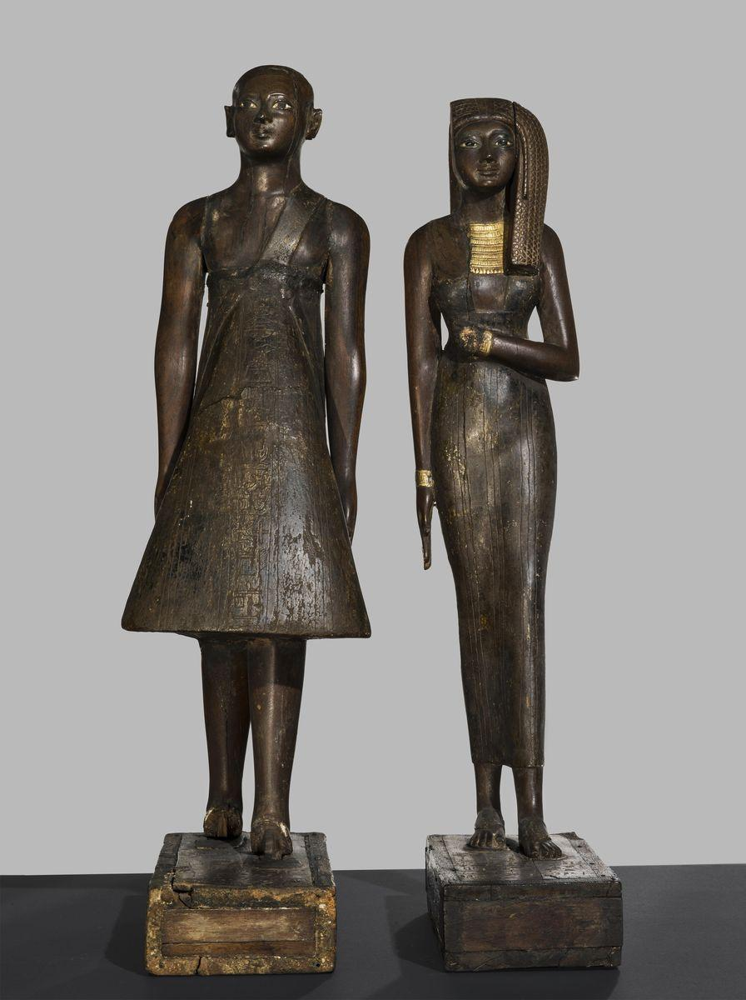

Размер изображения: 896 × 1200 пикселей
Источник: https://pushkinmuseum.art/data/fonds/ancient_east/1_1_a/1_1_a_2103__2099/index.php


In [11]:
image_response = requests.get(exhibit["image_url"], timeout=30)
image_response.raise_for_status()
exhibit_image = Image.open(io.BytesIO(image_response.content)).convert("RGB")

display(Markdown(f"### {exhibit['title']}"))
display(exhibit_image)
print(f"Размер изображения: {exhibit_image.width} × {exhibit_image.height} пикселей")
print(f"Источник: {exhibit['source_url']}")

Мультимодальная модель принимает изображение как URL или как data URL. Чтобы пример не зависел от
повторного доступа модели к внешнему сайту, преобразуем уже загруженный `PIL.Image` в JPEG,
кодируем байты в Base64 и сформируем `data:image/jpeg;base64,...`. Функция пригодится в обоих
следующих VLM-вызовах.

In [12]:
def image_to_data_url(image: Image.Image) -> str:
    buffer = io.BytesIO()
    image.convert("RGB").save(buffer, format="JPEG", quality=92)
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    return f"data:image/jpeg;base64,{encoded}"


exhibit_image_data_url = image_to_data_url(exhibit_image)
print(f"Изображение подготовлено для VLM: {len(exhibit_image_data_url):,} символов")

Изображение подготовлено для VLM: 187,547 символов


Сначала попросим VLM дать обычное подробное описание видимого. В запрос намеренно не
передаются название, эпоха и музейный текст: так можно увидеть, что модель извлекает именно
из фотографии. Инструкция требует отделять наблюдаемое от предположений и не называть людей
или датировку без визуальных оснований.

Ответ сохраним в `visual_description`. Его объём ограничен примерно 700 символами, чтобы
следующая демонстрация синтеза речи оставалась короткой и удобной для прослушивания.

In [14]:
vlm_response = client.responses.create(
    model=qwen36_model, # можете также попробовать deepseek_model
    instructions=(
        "Ты — специалист по тифлокомментированию музейных предметов. "
        "Опиши по-русски только то, что видно на фотографии: объект, позы, одежду, "
        "материалы, цвета, фактуру, композицию и заметные детали. "
        "Сначала дай общее впечатление, затем двигайся слева направо и сверху вниз. "
        "Не угадывай имена, точную эпоху или назначение. Объём — 500–700 символов."
    ),
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Составь подробное визуальное описание экспоната.",
                },
                {
                    "type": "input_image",
                    "image_url": exhibit_image_data_url,
                    "detail": "auto",
                },
            ],
        }
    ],
)

visual_description = vlm_response.output_text.strip()
display(Markdown(f"### Визуальное описание\n\n{visual_description}"))

### Визуальное описание

На фотографии представлены два древних статуарных изваяния из темной полированной древесины, монументально стоящие рядом на отдельных прямоугольных подставках. Обе фигуры покрыты темным лаком, местами потускневшим, что подчеркивает возраст и фактуру материала.

Фигура слева изображает человека в короткой плиссированной одежде, спускающейся до колен. Голова гладко острижена, глаза темные, выразительные, в профиль. Руки опущены вдоль тела, кисти сжаты. На груди и юбке видны следы золочения и едва различимые иероглифические линии. ступни плотно стоят на потертых деревянном основание, лишению цвета подставке видны вкрапления золотой фольги.

Фигура справа — женская. Голова покрыта париком или тканью, спускающейся до плеч. На шее — многослойное золотистое ожерелье. Оно из платья до щиколоток. Левая рука согнута и прижата к груди, на запястье и пальцах заметны золотые украшения. Статуи электрически серым фоном создают спокойную, строгую композицию.

Проделаем визуальный анализ с использованием того же структурного вывода, что и раньше.
Поля эпохи, стиля и техники здесь являются **визуальными гипотезами**, а не атрибуцией.

In [15]:
visual_description_response = client.responses.parse(
    model=qwen36_model,
    instructions=(
        "Анализируй только изображение, без внешних знаний об объекте. "
        "Отделяй наблюдение от гипотезы. Если эпоху, стиль или технику нельзя "
        "надёжно определить по фотографии, явно укажи неопределённость и низкую уверенность. "
        "Все значения верни ТОЛЬКО НА РУССКОМ ЯЗЫКЕ."
    ),
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Верни структурированный визуальный анализ этого экспоната.",
                },
                {
                    "type": "input_image",
                    "image_url": exhibit_image_data_url,
                    "detail": "auto",
                },
            ],
        }
    ],
    text_format=ExhibitDescription,
)

visual_analysis = visual_description_response.output_parsed
display(JSON(visual_analysis.model_dump(), expanded=True))

<IPython.core.display.JSON object>

## 6. Синтез речи: доступное описание экспоната

Для посетителя, которому трудно рассмотреть фотографию или прочитать текст, превратим описание экспоната в речь. Для этого используем технологию Yandex SpeechKit, которая вызывается через специальны AI Studio SDK. Выберем русский голос `jane`, формат WAV и немного замедленный темп, удобный для музейного аудиогида.

In [16]:
sdk = AIStudio(folder_id=folder_id, auth=api_key)

tts_text = child_description
tts = sdk.speechkit.text_to_speech(voice="jane", audio_format="WAV")
speech_result = tts.configure(speed=0.95).run(tts_text)

display(Audio(data=speech_result.data))

## 7. Художественная интерпретация с YandexART

Поскольку у нас есть визуальное описание объекта, полученное мультимодальной языковой моделью, мы можем попытаться нарисовать аналогичное изображение по текстовому описанию.

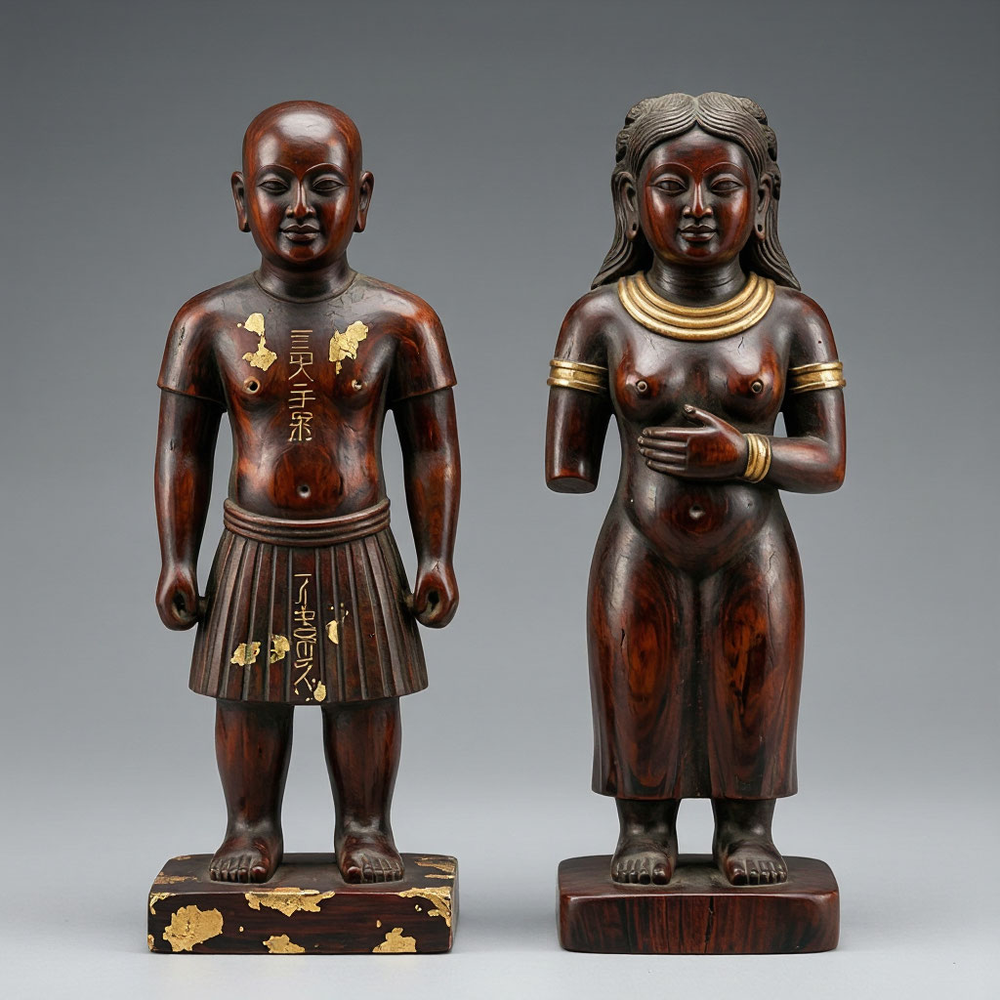

In [17]:
generated_response = client.images.generate(
    model=yandex_art_model,
    prompt=visual_description,
    n=1,
    size="1024x1024",
)

generated_bytes = base64.b64decode(generated_response.data[0].b64_json)
generated_image = Image.open(io.BytesIO(generated_bytes)).convert("RGB")
generated_image 

## 8. Обработка всех экспонатов

С помощью такой ИИ-обработки мы можем получить структурированный каталог всех объектов. Предположим, мы хотим разбить весь каталог объектов на структурированные блоки, и наладить поиск/фильтрацию по тегам и по близлежащим объектам. Для этого сначала попробуем выделить общие теги для всей коллекции и основные категории.

In [52]:
res = client.responses.create(
    model=deepseek_model,
    instructions="""
    Посмотри на общий файл описания всех экспонатов музея, и построй дерево навигации по экспонатам, на каждом уровне которого по 6-8 пунктов. Выведи результат в виде категорий и подкатегорий, не добавляя никаких дополнительных пояснений или текста, например:
    ```
    Живопись
    Живопись -> Франция
    Живопись -> Франция -> Импрессионизм
    ```
    Сами произведения в классификацию не включай. Предложи методику классификации, чтобы на каждом финальном уровне было по 4-5 произведений.
    """,
    input=json.dumps(exhibits,ensure_ascii=False)
)
s = res.output_text
s

'Живопись\nЖивопись -> Франция\nЖивопись -> Франция -> Классицизм\nЖивопись -> Франция -> Рококо\nЖивопись -> Франция -> Реализм\nЖивопись -> Франция -> Импрессионизм\nЖивопись -> Франция -> Постимпрессионизм\nЖивопись -> Франция -> Символизм\nЖивопись -> Франция -> Наби\nЖивопись -> Франция -> Фовизм\nЖивопись -> Германия\nЖивопись -> Германия -> Возрождение\nЖивопись -> Германия -> Романтизм\nЖивопись -> Германия -> Реализм\nЖивопись -> Германия -> Символизм\nЖивопись -> Германия -> Экспрессионизм\nЖивопись -> Голландия\nЖивопись -> Голландия -> Барокко\nЖивопись -> Голландия -> Постимпрессионизм\nЖивопись -> Фландрия\nЖивопись -> Фландрия -> Барокко\nЖивопись -> Испания\nЖивопись -> Испания -> Барокко\nЖивопись -> Испания -> Голубой период\nЖивопись -> Италия\nЖивопись -> Италия -> Возрождение\nЖивопись -> Италия -> Барокко\nЖивопись -> Италия -> Ведизм\nЖивопись -> Швейцария\nЖивопись -> Швейцария -> Символизм\nЖивопись -> Россия\nЖивопись -> Россия -> Авангард\nСкульптура\nСкульпт

Аналогичным образом получим заранее список возможных тегов:

In [56]:
res = client.responses.create(
    model=deepseek_model,
    instructions="""
    Посмотри на общий файл описания всех экспонатов музея, и построй множество тегов, по которым можно будет осуществлять поиск экспонатов. Теги должны указывать на отдельные предметы, представленные на экспонате, на временной период, на технику и т.д. Тегов должно быть много, но они не должны повторяться по смыслу. Выведи большой список тегов, по одному на строку. Названия произведений в теги не включай, теги должны быть короткими (3-10 символов).
    """,
    input=json.dumps(exhibits,ensure_ascii=False)
)
tags = res.output_text
tags

'скульптура\nживопись\nграфика\nархеология\nнумизматика\nприкладное\nслепки\nЕгипет\nФранция\nГолландия\nИталия\nГермания\nИспания\nЯпония\nРоссия\nВизантия\nДания\nШвейцария\nФландрия\nГреция\nАнтичность\nСредние века\nВозрождение\nXVII век\nXIX век\nXX век\nXVIII век\nДревний Египет\nНовое царство\nСреднее царство\nРимский Египет\nКоптское искусство\nФовизм\nИмпрессионизм\nПостимпрессионизм\nСимволизм\nРомантизм\nКлассицизм\nБарокко\nРококо\nРеализм\nКубизм\nАбстракция\nдерево\nмрамор\nбронза\nкерамика\nстекло\nпастель\nтемпера\nмасло\nэнкаустика\nксилография\nбазальт\nизвестняк\nслоновая кость\nэбеновое дерево\nпозолота\nэмаль\nлен\nхолст\nкартон\nпортрет\nпейзаж\nнатюрморт\nмифология\nрелигия\nжанровая сцена\nобнаженная\nкафе\nбалет\nцирк\nбатальный\nведута\nинтерьер\nаллегория\nхристианство\nБиблия\nантичные боги\nмадонна\nсвятые\nвосточные\nимпортный\nгробница\nпогребальный\nмумия\nжрец\nжрица\nфараон\nцарица\nимператор\nангел\nсатир\nвакханалия\nтанец\nцветы\nживотные\nрыбы\nлош

Теперь попросим LLM выдать нам структурированное описание для каждого экспоната:

In [61]:
class ExhibitDescription(BaseModel):
    tags: list[str] = Field(
        min_length=3,
        max_length=10,
        description="Короткие предметные теги",
    )
    description: str = Field(
        description="Краткое описание экспоната для музейной этикетки, 1 абзац текста, для 10-летнего ребёнка, без выдумок, простым языком, с объяснением сложных терминов",
    )
    category: str = Field(
        description="Категория произведения"
    )

prompt = f"""
Ты - музейный архивариус, твоя задача классифицировать музейные экспонаты, назначать им теги и категорию.
Посмотри на данные по экспонату, и сгенерируй по нему JSON, включающий в себя:
- category - категория экспоната из списка ниже
- tags - список подходящих тегов из списка ниже
- description - короткое описание экспоната длинною в один абзац текста для музейной карточки, ориентированное на 10-летнего ребенка

<categories>
{s}
</categories>
<tags>
{tags}
</tags>
"""

for i,x in enumerate(tqdm(exhibits)):
    res = client.responses.parse(
        model=model,
        instructions=prompt,
        input=json.dumps(x, ensure_ascii=False),
        text_format=ExhibitDescription,
    )
    res = res.output_parsed
    exhibits[i]['xtags'] = res.tags
    exhibits[i]['xdescription'] = res.description
    exhibits[i]['category'] = res.category 


  0%|          | 0/97 [00:00<?, ?it/s]

Запишем получившуюся информацию на диск в обогащенный JSON-файл:

In [62]:
with open('../data/pushkin-enrich.json','w',encoding='utf-8') as f:
    json.dump(exhibits,f,ensure_ascii=False)

Теперь нарисуем картинки для всех категорий:

In [67]:
def generate_image(prompt):
    res = client.images.generate(
        model=yandex_art_model,
        prompt=prompt,
        n=1,
        size="1024x1024")
    res = base64.b64decode(res.data[0].b64_json)
    return Image.open(io.BytesIO(res)).convert("RGB")

cats = {}

for i,x in enumerate(s.split('\n')):
    if '->' not in x:
        continue
    print(f"Generating for {x}")
    res = generate_image(f"Сгенерируй изображение thumbnail для следующего раздела каталога музейных экспонатов: {x}. Изображение должно отражать соответствующий вид искусства (живопись, скульптура и т.д.), равно как и другие географические и стилевые особенности указанного раздела. Изображение должно быть полноразмерной картиной или фотографией статуи, без рамки, а не изображением экспоната внутри музея.")
    res.save(f'../data/images/im_{i}.jpg')
    cats[x] = f'im_{i}.jpg'

Generating for Живопись -> Франция
Generating for Живопись -> Франция -> Классицизм
Generating for Живопись -> Франция -> Рококо
Generating for Живопись -> Франция -> Реализм
Generating for Живопись -> Франция -> Импрессионизм
Generating for Живопись -> Франция -> Постимпрессионизм
Generating for Живопись -> Франция -> Символизм
Generating for Живопись -> Франция -> Наби
Generating for Живопись -> Франция -> Фовизм
Generating for Живопись -> Германия
Generating for Живопись -> Германия -> Возрождение
Generating for Живопись -> Германия -> Романтизм
Generating for Живопись -> Германия -> Реализм
Generating for Живопись -> Германия -> Символизм
Generating for Живопись -> Германия -> Экспрессионизм
Generating for Живопись -> Голландия
Generating for Живопись -> Голландия -> Барокко
Generating for Живопись -> Голландия -> Постимпрессионизм
Generating for Живопись -> Фландрия
Generating for Живопись -> Фландрия -> Барокко
Generating for Живопись -> Испания
Generating for Живопись -> Испания

Запишем соответствие иконок и разделов:

In [70]:
with open('../data/images/generated/images.json','w',encoding='utf-8') as f:
    json.dump(cats,f,ensure_ascii=False)

## Выводы

Мы научились использовать ИИ-модели внутри Yandex AI Studio из программного кода:

- Responses API позволяет делать простые запросы и связный диалог через `previous_response_id`;
- LLM превратила длинный научный текст в понятную детскую этикетку;
- Pydantic-схема сделала смысловые теги предсказуемыми и пригодными для программной обработки;
- VLM описала фотографию и вернула отдельный структурированный визуальный анализ;
- SpeechKit превратил доступное описание в музейный аудиофрагмент;
- YandexART создал новую художественную интерпретацию на основе полученного описания.

Мы с вами также обработали всю коллекцию открытых данных и получили короткие описания, теги и категории, пригодные для навигации в приложении.

## Аппендикс

Для игры нам понадобится сгенерировать какое-то количество картин в разных жанрах.


In [74]:
impressionists = """
Клод Моне
Пьер-Огюст Ренуар
Камиль Писсарро
Альфред Сислей
Эдгар Дега
Берта Моризо
Мэри Кассат
Гюстав Кайботт
Арман Гийомен
Фредерик Базиль
"""

non_impressioninsts = """
Казимир Малевич
Пит Мондриан
Ад Рейнхардт
Фрэнк Стелла
Барнетт Ньюман
Эллсворт Келли
Сол Левитт
Дональд Джадд
Жозеф Кошут
Марсель Дюшан
"""

for i,(x,y) in enumerate(zip(impressionists.strip().split('\n'),non_impressioninsts.strip().split('\n'))):
    print(f"Generating for {x}")
    res = generate_image(f"Сгенерируй типовую картину с рамкой в стиле художника {x} в стиле импрессионизма")
    res.save(f'../data/images/game/im_{i}.jpg')
    print(f"Generating for {y}")
    res = generate_image(f"Сгенерируй типовую картину с рамкой в стиле художника {y}")
    res.save(f'../data/images/game/noim_{i}.jpg')
    

Generating for Клод Моне
Generating for Казимир Малевич
Generating for Пьер-Огюст Ренуар
Generating for Пит Мондриан
Generating for Камиль Писсарро
Generating for Ад Рейнхардт
Generating for Альфред Сислей
Generating for Фрэнк Стелла
Generating for Эдгар Дега
Generating for Барнетт Ньюман
Generating for Берта Моризо
Generating for Эллсворт Келли
Generating for Мэри Кассат
Generating for Сол Левитт
Generating for Гюстав Кайботт
Generating for Дональд Джадд
Generating for Арман Гийомен
Generating for Жозеф Кошут
Generating for Фредерик Базиль
Generating for Марсель Дюшан
